# UNCOMMENT INI KALO JALANIN NOTEBOOKNYA DI ENVIRONMENT YG GK PERSISTENT

In [ ]:
# paket-pakettttt
# %pip install pandas numpy matplotlib seaborn scikit-learn transformers torch torchinfo torchvision timm gdown

# dataset
# %pip install gdown
import gdown
import os
dataset_dir = './dataset/'
os.makedirs(dataset_dir, exist_ok=True)
gdown.download(url='https://drive.google.com/uc?id=1mK0Nf-jv_h2bgHUCRM4_EsdTiiitZ_Uj', output=dataset_dir, quiet=False)
gdown.download(url='https://drive.google.com/uc?id=1AOWzlOz5hmdO39dEmzhQ4z_nabgzi7Tu', output=dataset_dir, quiet=False)
gdown.download(url='https://drive.google.com/uc?id=1dJERrVlp7DlNSXk-uvbbG6Rv7uvqTOKd', output=dataset_dir, quiet=False)
gdown.download(url='https://drive.google.com/uc?id=1pODuKC4gP6-QDQonG8XTqI8w8ds68mE3', output=dataset_dir, quiet=False)

# pastiin udh install 7z dari package manager
!7z x ./dataset/dataset_image.zip

gdown.download(url='https://drive.google.com/file/d/1mFqB1Bd2YvUOtHVAnMjWQgVCzUECPpo-/view?usp=sharing', output=dataset_dir, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1mFqB1Bd2YvUOtHVAnMjWQgVCzUECPpo-
To: /mnt/d/Student/8th_semester-skripsi/bukan-skripsi/notebooks/1st_exp/datasetuhuh/dataset_translated.csv
100%|██████████| 4.95M/4.95M [00:16<00:00, 308kB/s]


'./datasetuhuh/dataset_translated.csv'

In [50]:
import pandas as pd
import numpy as np

from transformers import AutoTokenizer, AutoProcessor, AutoModel, AlbertTokenizer, AlbertModel
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from torchinfo import summary
from torch import nn
import timm

In [2]:
df = pd.read_csv("./dataset/dataset_translated.csv", delimiter=";", encoding="utf-8", dtype={"image_id": str, "label": int})

df.head()

,image_id,text,text_translated,label,split
0,840006160660983809,<user> thanks for showing up for our appointme...,<user> Terima kasih sudah datang ke janji temu...,1,train
1,908913372199915520,haha . # lol,haha . # lol,1,train
2,916496521406726145,i love waiting <num> min for a cab - such shor...,Aku suka menunggu <num> menit untuk taksi — be...,1,train
3,916364004129304576,22 super funny quotes # funnyquotes # funnysa...,22 kutipan super lucu #kutipanlucu #ucapanluc...,1,train
4,853866052589154304,goog morning # sorrynotsorry # morning,Selamat pagi # sorrynotsorry # pagi,1,train


In [3]:
#show some stats
print(df.describe())
print(df.info())

              label
count  24316.000000
mean       0.421369
std        0.493789
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
<class 'pandas.DataFrame'>
RangeIndex: 24316 entries, 0 to 24315
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   image_id         24316 non-null  str  
 1   text             24316 non-null  str  
 2   text_translated  24316 non-null  str  
 3   label            24316 non-null  int64
 4   split            24316 non-null  str  
dtypes: int64(1), str(4)
memory usage: 950.0 KB
None


In [4]:
#check the target distribution
print(df['label'].value_counts())

label
0    14070
1    10246
Name: count, dtype: int64


In [5]:
# drop NaN values
df = df.dropna()

# drop rows with missing image in ./dataset/dataset_image/<image_id>.jpg
def check_image_exists(image_id):
    try:
        img = Image.open(f"./dataset/dataset_image/{image_id}.jpg")
        return True
    except FileNotFoundError:
        print(f"Image {image_id} not found.")
        return False
df['image_exists'] = df['image_id'].apply(check_image_exists)

# count how many images are missing
print(df['image_exists'].value_counts())

image_exists
True    24316
Name: count, dtype: int64


In [6]:
df.head()

,image_id,text,text_translated,label,split,image_exists
0,840006160660983809,<user> thanks for showing up for our appointme...,<user> Terima kasih sudah datang ke janji temu...,1,train,True
1,908913372199915520,haha . # lol,haha . # lol,1,train,True
2,916496521406726145,i love waiting <num> min for a cab - such shor...,Aku suka menunggu <num> menit untuk taksi — be...,1,train,True
3,916364004129304576,22 super funny quotes # funnyquotes # funnysa...,22 kutipan super lucu #kutipanlucu #ucapanluc...,1,train,True
4,853866052589154304,goog morning # sorrynotsorry # morning,Selamat pagi # sorrynotsorry # pagi,1,train,True


In [58]:
# show some random data with the image
import random
random_row = df.sample(n=1).iloc[0]
print(f"Text: {random_row['text']}")
print(f"Label: {random_row['label']}")
img = Image.open(f"./dataset/dataset_image/{random_row['image_id']}.jpg")
img.show()

Text: when you 're enjoying your day but then remember you go back to school tomorrow and your sleeping schedule is messed up
Label: 0


# POC

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
class SimpleSarcasmDataset(Dataset):
    def __init__(self, data, tokenizer, processor):
        self.data = data
        self.tokenizer = tokenizer
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        text_inputs = self.tokenizer(item['text_translated'], return_tensors="pt", padding='max_length', truncation=True, max_length=128)
        
        image = Image.open(f"./dataset/dataset_image/{item['image_id']}.jpg").convert("RGB")
        image_inputs = self.processor(images=image, return_tensors="pt")
        
        return {
            'input_ids': text_inputs['input_ids'],
            'pixel_values': image_inputs['pixel_values'],
            'label': torch.tensor(item['label'], dtype=torch.float)
        }

In [9]:
#dataset split
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# Get all indices and labels
indices = list(range(len(df)))
labels = df.label

# Split indices (stratify=labels ensures both sets have the same class proportions)
train_indices, val_indices = train_test_split(indices, test_size=0.3, stratify=labels)

# Create virtual subsets using these indices
train_dataset_subset = Subset(df, train_indices)
val_dataset_subset = Subset(df, val_indices)

In [73]:
text_model_name = "indobenchmark/indobert-lite-base-p2"
# vision_model_name = "WinKawaks/vit-small-patch16-224"
vision_model_name = "google/vit-base-patch16-224"

In [74]:
tokenizer = AutoTokenizer.from_pretrained(text_model_name)

print(f"Max length: {tokenizer.model_max_length}")
print(f"Vocab size: {tokenizer.vocab_size}")

dummy_text = "Contoh teks untuk tokenisasi."
encoded = tokenizer(dummy_text, return_tensors="pt", padding='max_length', truncation=True, max_length=128)
print(encoded)

print(f"Input IDs shape: {encoded['input_ids'].shape}")

# reverse tokenization
decoded_text = tokenizer.decode(encoded['input_ids'][0], skip_special_tokens=False)
print(f"Decoded text: {decoded_text}")

Max length: 1000000000000000019884624838656
Vocab size: 5
{'input_ids': tensor([[2, 1, 1, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])}
Input IDs shape: torch.Size(

In [61]:
processor = AutoProcessor.from_pretrained(vision_model_name)

# 1. See what the model expects for dimensions
print(f"Expected size: {processor.size}") 

# 2. See normalization values (Mean and Std)
print(f"Mean: {processor.image_mean}")
print(f"Std: {processor.image_std}")

# 3. Check the output shape with a dummy image (e.g., a random tensor)
import torch
dummy_image = torch.randn(3, 500, 500) # Simulating a 500x500 RGB image
pixel_values = processor(dummy_image, return_tensors="pt")["pixel_values"]

print(f"Processed image shape: {pixel_values.shape}")
# Likely [1, 3, 224, 224]

Expected size: SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)
Mean: (0.5, 0.5, 0.5)
Std: (0.5, 0.5, 0.5)
Processed image shape: torch.Size([1, 3, 224, 224])


In [13]:
# 1. Set global seeds
torch.manual_seed(42)

# 2. Create a local generator with a specific seed
g = torch.Generator()
g.manual_seed(42)

train_dataset = DataLoader(SimpleSarcasmDataset(train_dataset_subset.dataset.to_dict(orient='records'), tokenizer, processor), batch_size=8, shuffle=True, generator=g)
val_dataset = DataLoader(SimpleSarcasmDataset(val_dataset_subset.dataset.to_dict(orient='records'), tokenizer, processor), batch_size=8, shuffle=False)

In [14]:
class SarcasmModel(nn.Module):
    def __init__(self, text_model, vision_model):
        super().__init__()
        self.text_encoder = text_model
        self.vision_encoder = vision_model
        
        # # Freezing encoders for PoC/Baseline
        # for param in self.text_encoder.parameters(): param.requires_grad = False
        # for param in self.vision_encoder.parameters(): param.requires_grad = False

        # batch_first=True makes it much more intuitive (matches TF/Keras style)
        self.cross_attention = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        
        self.norm = nn.LayerNorm(768)
        
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, pixel_values):
        # # 1. Feature Extraction (No Gradients for frozen models)
        # with torch.no_grad():
        # Text: [Batch, 768]
        t_feat = self.text_encoder(input_ids).pooler_output
        # Vision Patches: [Batch, 196, 768] (removing the CLS token at index 0)
        v_feat = self.vision_encoder(pixel_values).last_hidden_state[:, 1:, :]
        
        # 2. Shape Alignment: Text needs a sequence dimension for MHA
        t_feat = t_feat.unsqueeze(1) # Shape: [B, 1, 768]
        
        # 3. Cross-Attention: Text queries the Image Patches
        # attn_output shape: [B, 1, 768]
        attn_output, attn_weights = self.cross_attention(query=t_feat, 
                                                         key=v_feat, 
                                                         value=v_feat)
        
        # 4. Residual + Norm
        fused = self.norm(t_feat + attn_output)
        
        # 5. Classification
        # We squeeze(1) to go from [B, 1, 768] -> [B, 768]
        logits = self.classifier(fused.squeeze(1))
        
        return logits, attn_weights

In [15]:
text_model = AutoModel.from_pretrained(text_model_name)
# vision_model = AutoModel.from_pretrained("google/vit-base-patch16-224")
vision_model = AutoModel.from_pretrained(vision_model_name)
model = SarcasmModel(text_model, vision_model).to(device)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 727.20it/s]
ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
# Define dummy inputs that match the shapes you found above
batch_size = 8
seq_len = 128 # or tokenizer.model_max_length
img_size = 224

# Create dummy tensors
dummy_input_ids = torch.zeros((batch_size, seq_len), dtype=torch.long).to(device)
dummy_pixel_values = torch.zeros((batch_size, 3, img_size, img_size)).to(device)

# Print the summary
print(summary(model, input_data=[dummy_input_ids, dummy_pixel_values]))

# remove the dummy tensors to free up memory
del dummy_input_ids
del dummy_pixel_values

Layer (type:depth-idx)                                       Output Shape              Param #
SarcasmModel                                                 [8, 1]                    --
├─AlbertModel: 1-1                                           [8, 768]                  --
│    └─AlbertEmbeddings: 2-1                                 [8, 128, 128]             --
│    │    └─Embedding: 3-1                                   [8, 128, 128]             3,840,000
│    │    └─Embedding: 3-2                                   [8, 128, 128]             256
│    │    └─Embedding: 3-3                                   [1, 128, 128]             65,536
│    │    └─LayerNorm: 3-4                                   [8, 128, 128]             256
│    │    └─Dropout: 3-5                                     [8, 128, 128]             --
│    └─AlbertTransformer: 2-2                                [8, 128, 768]             --
│    │    └─Linear: 3-6                                      [8, 128, 768]        

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

In [18]:
#train
epochs = 10
for t in range(epochs):
    model.train()
    correct = 0
    total = 0
    for item in train_dataset:
        input_ids = item['input_ids'].to(device)
        pixel_values = item['pixel_values'].to(device)
        label = item['label'].to(device)

        # print("Input IDs shape:", input_ids.shape) # [B, 1, 128]
        # print("Pixel values shape:", pixel_values.shape) # [B, 1, 3, 224, 224]
        # print("Label shape:", label.shape) # [B]

        fixed_input_ids = input_ids.squeeze(1)          # [B, 128]
        fixed_pixel_values = pixel_values.squeeze(1)    # [B, 3, 224, 224]
        fixed_label = label.unsqueeze(1)     # [B, 1]

        # print("Fixed Input IDs shape:", fixed_input_ids.shape)
        # print("Fixed Pixel values shape:", fixed_pixel_values.shape)
        # print("Fixed Label shape:", fixed_label.shape)

        output_logits, weights = model(fixed_input_ids, fixed_pixel_values)
        output = torch.sigmoid(output_logits)

        pred = (output > 0.5).float()
        correct += (pred == fixed_label).sum().item()
        total += fixed_label.size(0)
        # print(f"Output: {output.item():.4f}, Label: {label.item():.0f}")
        # print(f"Output[0]: {output[0].item():.4f}, Label[0]: {label[0].item():.0f}")
        loss = criterion(output, fixed_label.view_as(output))
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # free up memory
        del input_ids
        del pixel_values
        del label
        del fixed_input_ids
        del fixed_pixel_values
        del fixed_label
    epoch_acc = 100 * correct / total

    print(f'Epoch [{t+1}/{epochs}], Correst: {correct}, Total: {total}, Loss: {loss.item():.4f}, Accuracy: {epoch_acc:.2f}%')

Epoch [1/10], Correst: 17080, Total: 24316, Loss: 0.6254, Accuracy: 70.24%
Epoch [2/10], Correst: 17677, Total: 24316, Loss: 0.9558, Accuracy: 72.70%
Epoch [3/10], Correst: 18611, Total: 24316, Loss: 1.0819, Accuracy: 76.54%
Epoch [4/10], Correst: 19574, Total: 24316, Loss: 0.5051, Accuracy: 80.50%
Epoch [5/10], Correst: 20776, Total: 24316, Loss: 0.0465, Accuracy: 85.44%
Epoch [6/10], Correst: 21733, Total: 24316, Loss: 0.0575, Accuracy: 89.38%
Epoch [7/10], Correst: 22365, Total: 24316, Loss: 0.1337, Accuracy: 91.98%
Epoch [8/10], Correst: 22759, Total: 24316, Loss: 0.2550, Accuracy: 93.60%
Epoch [9/10], Correst: 22921, Total: 24316, Loss: 0.2324, Accuracy: 94.26%
Epoch [10/10], Correst: 23039, Total: 24316, Loss: 0.0127, Accuracy: 94.75%


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [25]:
def plot_attention_map(image_tensor, attn_weights, title="Attention Map"):
    """
    image_tensor: [3, 224, 224] (The original processed image)
    attn_weights: [1, 196] (The weights for this specific image)
    """
    # 1. Reshape to spatial grid (14x14)
    # Assuming 196 patches (14*14 = 196)
    grid_size = int(np.sqrt(attn_weights.shape[-1])) # Should be 14
    heatmap = attn_weights.view(grid_size, grid_size).detach().cpu().numpy()

    # 2. Normalize for visualization
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    # 3. Upscale to image size (224x224)
    # We use bilinear interpolation for a smooth "glow" effect
    heatmap_resized = cv2.resize(heatmap, (224, 224))

    # 4. Prepare the original image
    # Convert from [3, 224, 224] tensor to [224, 224, 3] numpy
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    # Un-normalize if you used ImageProcessor normalization
    img = (img - img.min()) / (img.max() - img.min())

    # 5. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    # Overlay heatmap on image
    ax[1].imshow(img)
    ax[1].imshow(heatmap_resized, cmap='jet', alpha=0.5) # alpha controls transparency
    ax[1].set_title(title)
    ax[1].axis('off')

    plt.show()

# Example usage:
# plot_attention_map(pixel_values[0], weights[0])

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


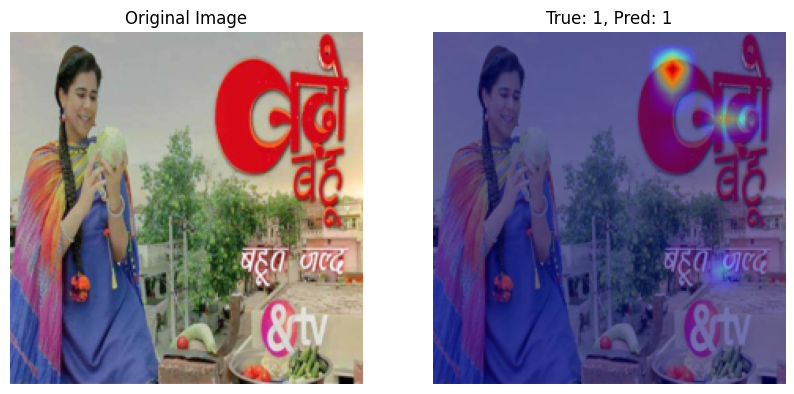

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


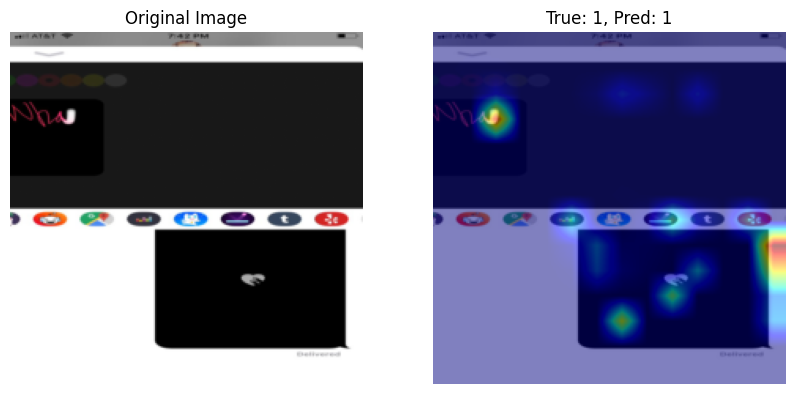

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


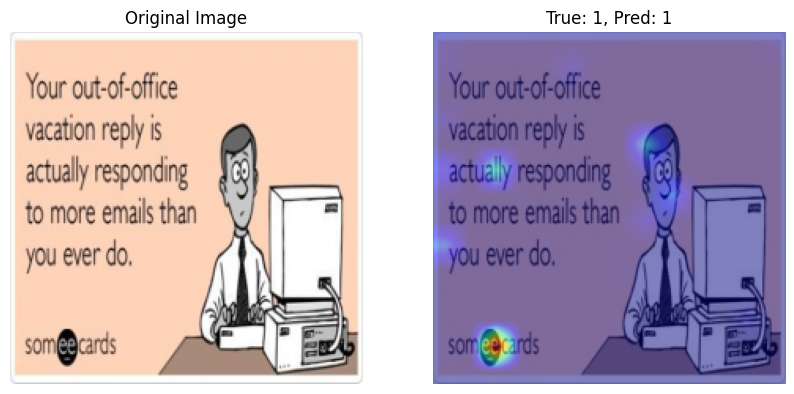

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


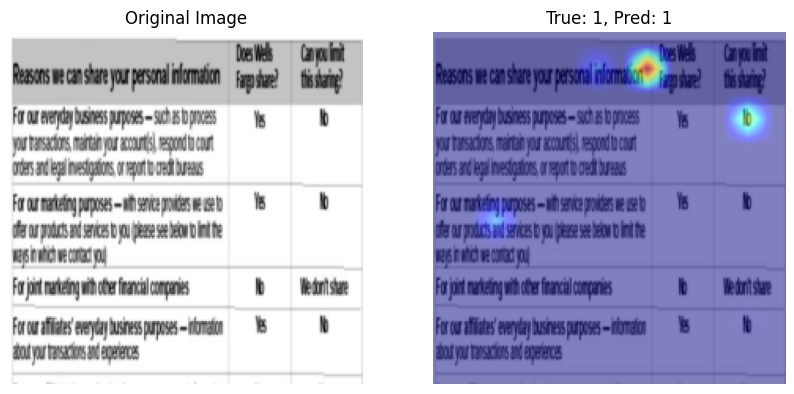

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


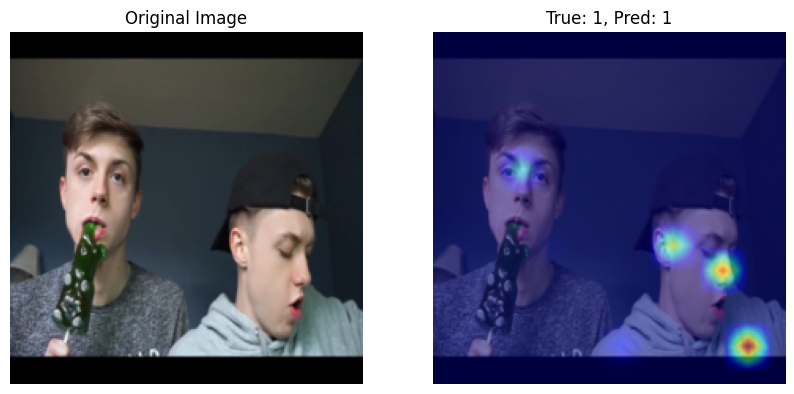

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


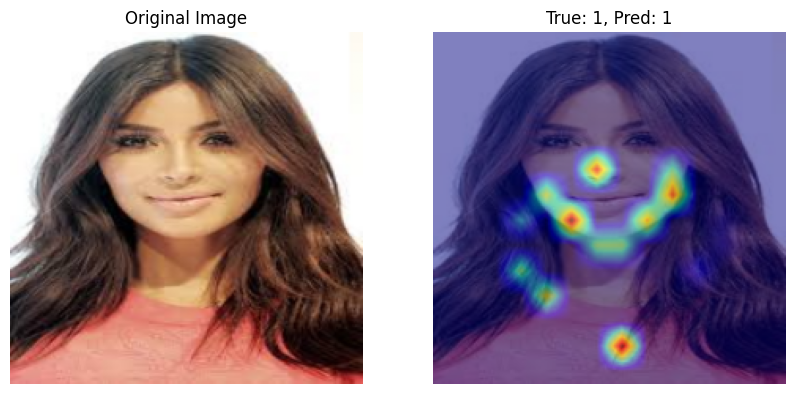

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


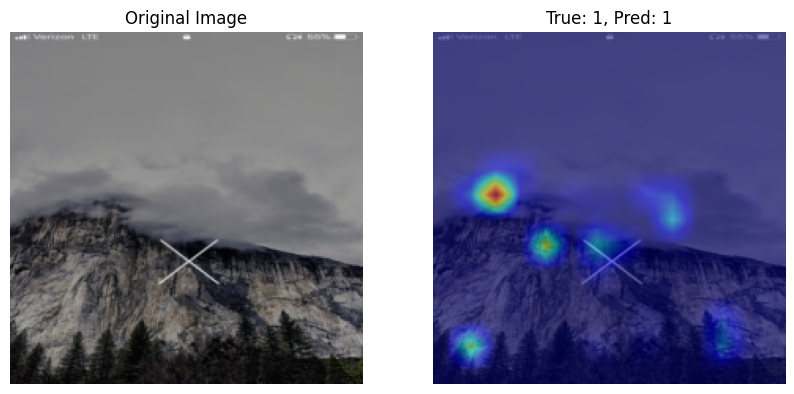

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


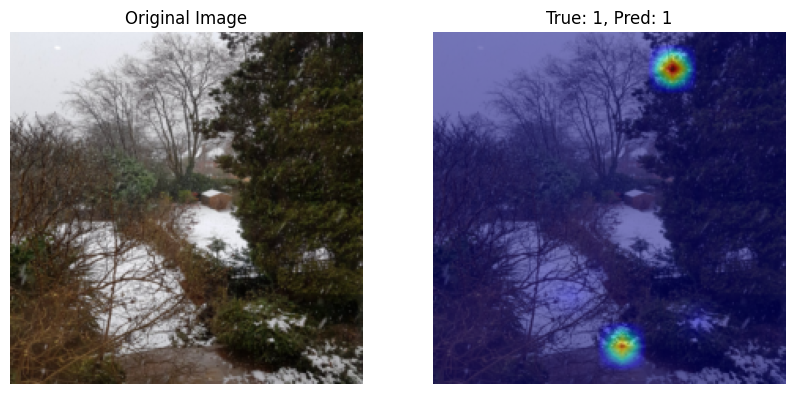

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


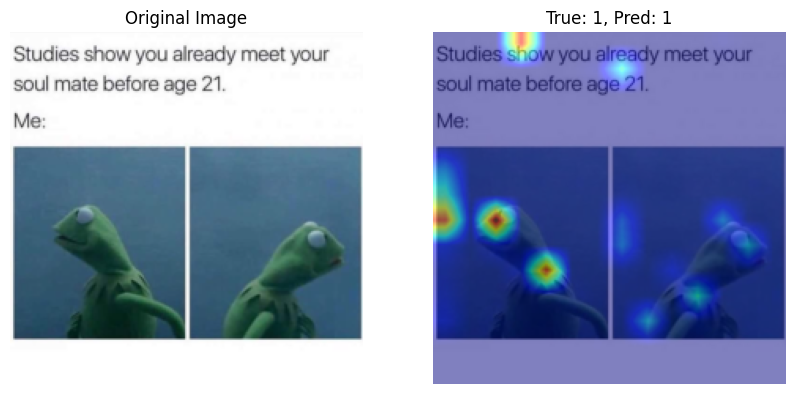

True: 1, Pred: 1
Text: 
tensor([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


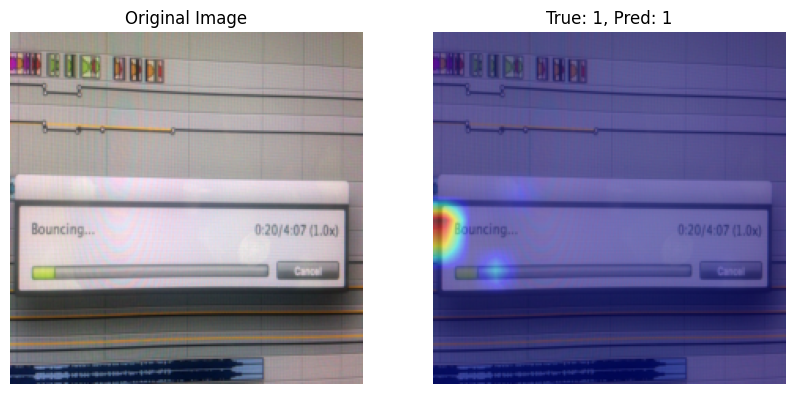

KeyboardInterrupt: 

In [30]:
#test
model.eval()
correct = 0
total = 0
preview_count = 0
max_previews = 10
with torch.no_grad():
    for item in val_dataset:
        input_ids = item['input_ids'].to(device)
        pixel_values = item['pixel_values'].to(device)
        label = item['label'].to(device)

        # print("Input IDs shape:", input_ids.shape) # [B, 1, 128]
        # print("Pixel values shape:", pixel_values.shape) # [B, 1, 3, 224, 224]
        # print("Label shape:", label.shape) # [B]

        fixed_input_ids = input_ids.squeeze(1)          # [B, 128]
        fixed_pixel_values = pixel_values.squeeze(1)    # [B, 3, 224, 224]
        fixed_label = label.unsqueeze(1)     # [B, 1]

        output_logits, weights = model(fixed_input_ids, fixed_pixel_values)
        output = torch.sigmoid(output_logits)
        pred = (output > 0.5).float()
        correct += (pred == fixed_label).sum().item()
        total += fixed_label.size(0)


        show_preview = torch.rand(1).item() < 0.5 and preview_count < max_previews
        if show_preview:
                preview_count += 1
                # Pick one random sample from this batch and plot its attention
                batch_size = 8
                rand_idx = torch.randint(0, batch_size, (1,)).item()

                print(f"True: {fixed_label[rand_idx].item():.0f}, Pred: {pred[rand_idx].item():.0f}")
                print(f"Text: {tokenizer.decode(fixed_input_ids[rand_idx], skip_special_tokens=True)}")
                print(fixed_input_ids[rand_idx])

                # weights shape: [B, 1, 196] -> take sample and squeeze the seq dim
                attn_sample = weights[rand_idx].squeeze(0)
                plot_attention_map(fixed_pixel_values[rand_idx], attn_sample,
                                title=f"True: {fixed_label[rand_idx].item():.0f}, Pred: {pred[rand_idx].item():.0f}")
                # for i in range(len(fixed_label)):
                #     print(f"True: {fixed_label[i].item():.0f}, Pred: {pred[i].item():.0f}")
                #     # print text
                #     print(f"Text: {tokenizer.decode(fixed_input_ids[i], skip_special_tokens=True)}")
                #     plot_attention_map(fixed_pixel_values[i], weights[i], title=f"True: {fixed_label[i].item():.0f}, Pred: {pred[i].item():.0f}")
epoch_acc = 100 * correct / total
print(f'Validation Accuracy: {epoch_acc:.2f}%')

In [22]:
# # try to do some inference from external data
# image = Image.open("./images.jpeg").convert("RGB")
# image_inputs = processor(images=image, return_tensors="pt").to(device)
# text_inputs = tokenizer("Wah kamarnya sangat rapi, kamu pasti sangat rajin membersihkan", return_tensors="pt", padding='max_length', truncation=True, max_length=128).to(device)

# model.eval()
# with torch.no_grad():
#     output = model(text_inputs['input_ids'], image_inputs['pixel_values'])
#     print(f"Inference Output: {output.item():.4f}")
#     pred = (output > 0.5).float()
#     print(f"Inference Prediction: {'Sarcastic' if pred.item() == 1 else 'Not Sarcastic'}")